In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score


In [11]:
# =============================
# 2. Load Data
# =============================
df = pd.read_csv('HousePricePrediction.csv')


In [12]:
# =============================
# 3. EDA
# =============================
print(df.head())
print(df.info())
print(df.describe())



   Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0   0          60       RL     8450    Inside     1Fam            5   
1   1          20       RL     9600       FR2     1Fam            8   
2   2          60       RL    11250    Inside     1Fam            5   
3   3          70       RL     9550    Corner     1Fam            5   
4   4          60       RL    14260       FR2     1Fam            5   

   YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0       2003          2003     VinylSd         0.0        856.0   208500.0  
1       1976          1976     MetalSd         0.0       1262.0   181500.0  
2       2001          2002     VinylSd         0.0        920.0   223500.0  
3       1915          1970     Wd Sdng         0.0        756.0   140000.0  
4       2000          2000     VinylSd         0.0       1145.0   250000.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #  

In [14]:
from sklearn.impute import SimpleImputer

# Separate numeric and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Impute numeric columns
num_imputer = SimpleImputer(strategy='mean')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Impute categorical columns
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [16]:
# Select only numeric columns
num_df = df.select_dtypes(include=['int64', 'float64'])

# IQR calculation
Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1

# Filter outliers
num_df = num_df[~((num_df < (Q1 - 1.5 * IQR)) | (num_df > (Q3 + 1.5 * IQR))).any(axis=1)]

# Keep only rows that are not removed
df = df.loc[num_df.index]

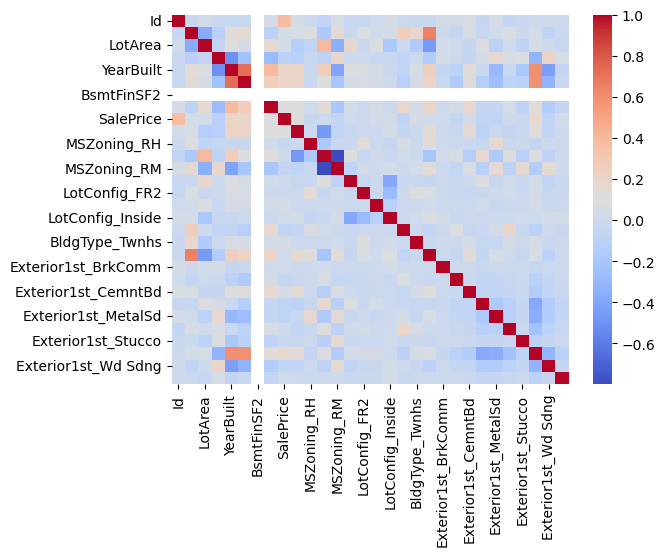

In [18]:
df = pd.get_dummies(df, drop_first=True)

sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()


In [19]:
# =============================
# 7. Split Features & Target
# =============================
target = df.columns[-1]
X = df.drop(columns=[target])
y = df[target]


In [20]:
# =============================
# 8. Feature Selection
# =============================
selector = SelectKBest(score_func=f_regression, k=5)
X = selector.fit_transform(X, y)

In [21]:
# =============================
# 9. Train Test Split
# =============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [22]:
# =============================
# 10. Scaling
# =============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
# =============================
# 11. Apply Algorithms
# =============================
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
    results[name] = score
    print(f"{name} Accuracy (R2): {score}")


Linear Regression Accuracy (R2): 0.01811445605350992
Decision Tree Accuracy (R2): -1.5354609929078005
Random Forest Accuracy (R2): -0.3960248226950347


In [24]:
# =============================
# 12. Choose Best Model
# =============================
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)


Best Model: Linear Regression


In [25]:
# =============================
# 13. Save Model
# =============================
pickle.dump(best_model, open('best_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print("Model Saved Successfully!")


Model Saved Successfully!
